Interaktywne wizualizacje z Plotly możemy tworzyć na kilka sposobów: pierwszym z nich jest tworzenie wykresów wprost z obiektu DataFrame. W tym celu będziemy musieli wykorzystać zewnętrzną bibliotekę Cufflinks, która będzie bezpośrednim łącznikiem pomiędzy Pandas a Plotly. Kolejnym sposobem jest tworzenie wizualizacji bezpośrednio w sposób zgodny z dokumentacją Plotly.

# Cufflinks, czyli Plotly prosto z Pandas

In [1]:
import plotly.offline as pyo
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot

init_notebook_mode(connected=True)

In [2]:
import cufflinks as cf
cf.go_offline()

In [3]:
import pandas as pd
df = pd.read_csv('OECDBLI2017.csv')
df.head()

,Country,Dwellings without basic facilities as pct,Housing expenditure as pct,Rooms per person as rat,Household net adjusted disposable income in usd,Household net financial wealth in usd,Labour market insecurity as pct,Employment rate as pct,Long-term unemployment rate as pct,Personal earnings in usd,...,Water quality as pct,Stakeholder engagement for developing regulations as avg score,Voter turnout as pct,Life expectancy in yrs,Self-reported health as pct,Life satisfaction as avg score,Feeling safe walking alone at night as pct,Homicide rate as rat,Employees working very long hours as pct,Time devoted to leisure and personal care in hrs
0,Australia,1.1,20,2.3,33417,57462,4.3,72,1.36,52063,...,92,2.7,91,82.5,85,7.3,63.6,1.0,13.20,14.35
1,Austria,1.0,21,1.6,32544,59574,2.7,72,1.94,48295,...,93,1.3,75,81.3,70,7.0,80.7,0.4,6.78,14.55
2,Belgium,2.3,21,2.2,29968,104084,4.8,62,3.98,49587,...,84,2.2,89,81.1,75,6.9,70.7,1.0,4.31,15.77
3,Canada,0.2,22,2.5,29850,85758,3.9,73,0.81,48403,...,91,3.0,68,81.5,88,7.3,80.9,1.4,3.73,14.41
4,Chile,9.4,18,1.9,16588,21409,8.1,62,2.02,28434,...,69,1.5,49,79.1,57,6.7,51.1,4.5,10.06,14.90


In [4]:
df.loc[0]

Country                                                           Australia
Dwellings without basic facilities as pct                               1.1
Housing expenditure as pct                                               20
Rooms per person as rat                                                 2.3
Household net adjusted disposable income in usd                       33417
Household net financial wealth in usd                                 57462
Labour market insecurity as pct                                         4.3
Employment rate as pct                                                   72
Long-term unemployment rate as pct                                     1.36
Personal earnings in usd                                              52063
Quality of support network as pct                                        94
Educational attainment as pct                                            80
Student skills as avg score                                             502
Years in edu

Baza danych zawiera zestawienie poszczególnych wskaźników raportowanych przez państwa OECD za rok 2017.

# Interaktywny wykres

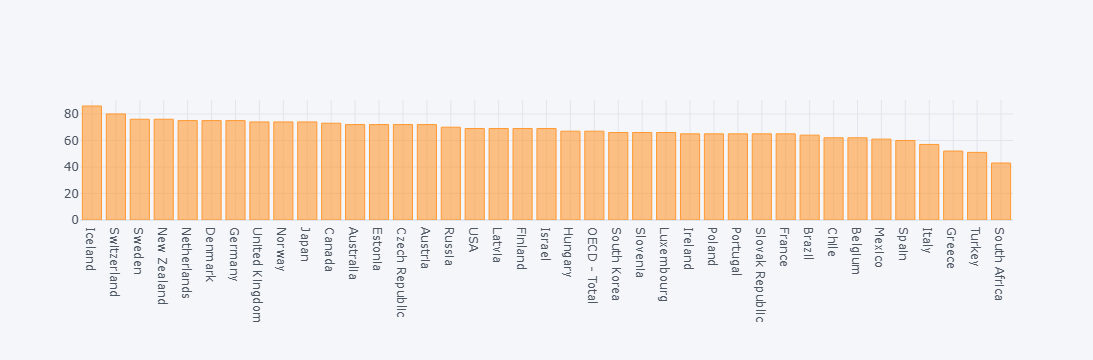

In [5]:
df.set_index('Country')['Employment rate as pct'].sort_values(ascending=False).iplot(kind='bar')

Na początek stwórzmy wykres kolumnowy, w którym zestawimy wszystkie państwa pod kątem stopy zatrudnienia (Employment rate as pct). Dzięki cufflinks, możemy to zrobić w niemalże identyczny sposób, jak robiliśmy to w przypadku wykresów Matplotlib. Jedyną różnicą jest to, że zamiast funkcji plot wywołujemy iplot, a jako jej jedyny argument wprowadzamy kind=’bar’, aby otrzymać wykres kolumnowy.

W kolejnym kroku zestawimy na wykresie punktowym stopę zatrudnienia (Employment rate as pct) ze wskaźnikiem dotyczącym niepewności na rynku pracy w ujęciu procentowym. W porównaniu do poprzedniego przykładu uzupełnimy wykres o dodatkowe informacje: opis osi x oraz osi y.

Argumenty x i y dotyczą kolumn, których będziemy używać do stworzenia wykresu. Niezwykle istotny jest parametr mode=’markers’, bez niego bowiem Plotly będzie interpretować wykres jako liniowy nawet pomimo sprecyzowania rodzaju wykresu jako ‘scatter’.

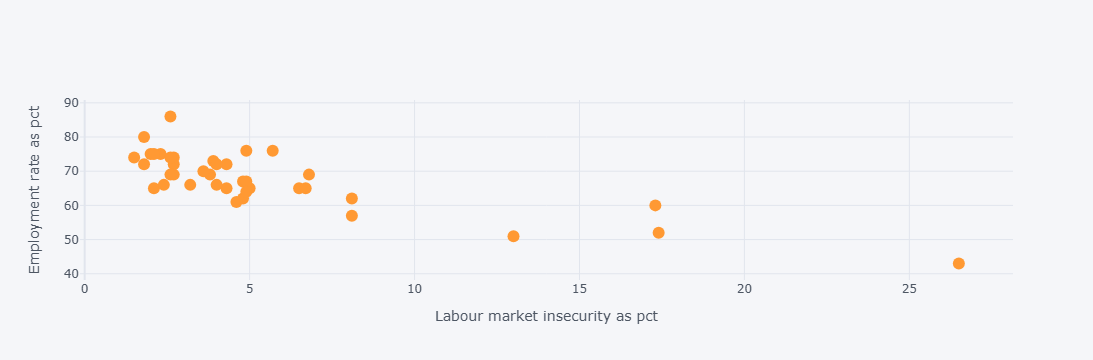

In [6]:
df.iplot(  # tworzy interaktywny wykres Plotly dla DataFrame
    kind='scatter',  # typ wykresu: wykres rozrzutu
    x='Labour market insecurity as pct',  # kolumna używana dla osi X
    y='Employment rate as pct',  # kolumna używana dla osi Y
    mode='markers',  # wyświetla tylko punkty bez linii
    xTitle='Labour market insecurity as pct',  # tytuł osi X
    yTitle='Employment rate as pct',  # tytuł osi Y
    text='Country'  # pokazuje nazwę kraju po najechaniu na punkt
)

Kolejny przykład dotyczy stworzenia histogramu. W tym przypadku jedyne, co musimy zrobić, to uzupełnić funkcję iplot o argument kind=’hist’.

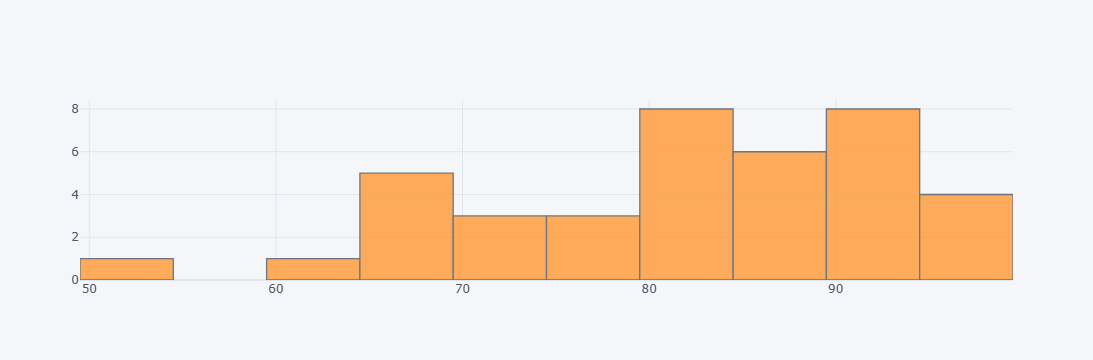

In [7]:
df['Water quality as pct'].iplot(kind='hist')

Korzystając z Plotly, zyskujemy dużą przewagę dzięki tzw. bubble plots. To nic innego jak wykres punktowy, w którym rozmiar każdego punktu jest powiązany z jakąś trzecią zmienną. Dla przykładu zbudujemy wykres bąbelkowy, w którym na osi x zestawimy zanieczyszczenie powietrza z jakością wody pitnej na osi y.

To zestawienie uzupełnimy o dodatkowy wymiar – przeciętny poziom zamożności gospodarstwa domowego wyrażony w dolarach. Dane dotyczące zamożności gospodarstw domowych wprowadzamy jako argument size funkcji iplot

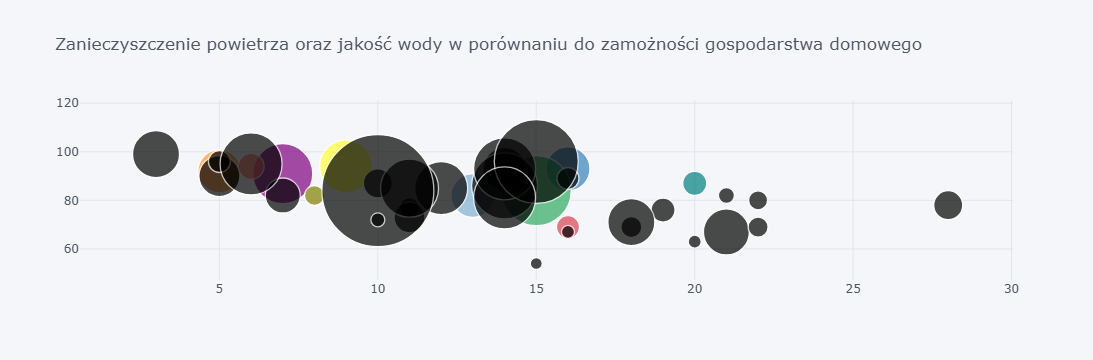

In [9]:
df.iplot(kind='bubble',
         x='Air pollution in ugm3',
         y='Water quality as pct',
         size='Household net financial wealth in usd',
        title='Zanieczyszczenie powietrza oraz jakość wody w porównaniu do zamożności gospodarstwa domowego',
        text='Country')

Dzięki takiemu sposobowi przedst|awienia danych możemy porównać, jak w statystykach dotyczących dbania o środowisko wypadają kraje o dużych dochodach w stosunku do krajów o mniejszych dochodach. Możemy zatem zauważyć, że w czołówce krajów o najlepszych standardach dotyczących wody pitnej i jakości powietrza znajdują się kraje o przeciętnym poziomie zamożności. Z kolei kraje o największych dochodach znajdują się mniej więcej w środku stawki, jeśli chodzi o wskaźniki środowiskowe.

Zanim zaczniemy omawiać bardziej zaawansowane sposoby tworzenia wykresów bez używania cufflinks, pokażemy możliwości Plotly w kontekście tworzenia trójwymiarowych wykresów.

Stwórzmy w tym celu nowy DataFrame

In [10]:
df2 = pd.DataFrame({'x':[1,2,3,4,5],'y':[10,20,30,20,10],'z':[5,4,3,2,1]})

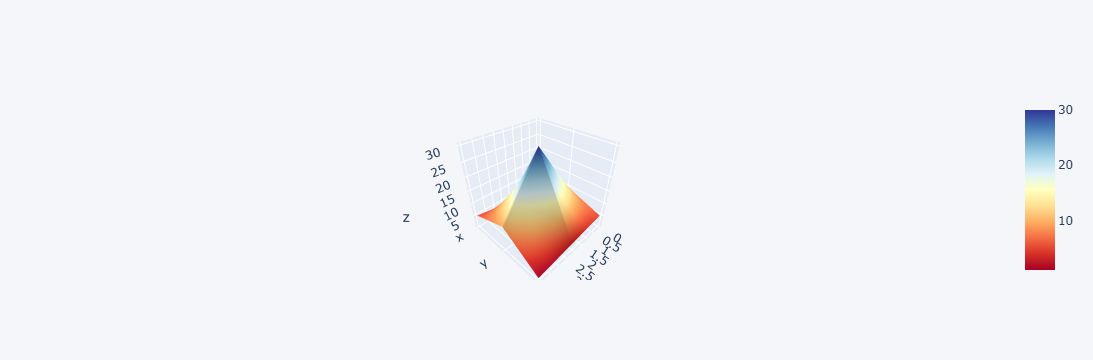

In [11]:
df2.iplot(kind='surface',colorscale='rdylbu')

# Tworzenie wizualizacji w stylu Plotly

Omówiliśmy do tej pory sposób tworzenia wykresów wprost z obiektu DataFrame. Teraz pokażemy jak tworzyć wykresy “w stylu Plotly”. Tworzenie wykresów bezpośrednio z Pandas będzie się nam przydawać do szybkiej wizualizacji lub jeśli podsumowanie analizy będzie dystrybuowane w formie pliku HTML wyeksportowanego z Jupyter Notebook.

Drugi sposób będzie bardziej zasadny przy okazji tworzenia dashboardów – o czym przekonamy się w dalszej części modułu.

Od teraz każda wizualizacja, którą będziemy robić wykorzystując Plotly, będzie uzależniona od importu dwóch obiektów:

In [12]:
import plotly.offline as pyo
import plotly.graph_objects as go

W dokumentacji Plotly możemy spotkać się z dwoma sposobami tworzenia wykresów, które są równoznaczne pod kątem możliwych do wykorzystania funkcjonalności. Pierwszy z nich zaprezentujemy na przykładzie wykresu punktowego, w którym zestawiamy stopę zatrudnienia ze wskaźnikiem niepewności rynku pracy.

W tym podejściu zapisujemy do zmiennej obiekt reprezentujący wybrany przez nas rodzaj wykresu. Zgodnie z konwencją kolejne wykresy, które będziemy chcieli nanieść na płótno, przypisujemy kolejno do zmiennych trace0, trace1, trace2 ... itd.

In [14]:
trace0 = go.Scatter(  # tworzy obiekt wykresu rozrzutu (scatter plot)
    x=df['Labour market insecurity as pct'],  # dane dla osi X
    y=df['Employment rate as pct'],  # dane dla osi Y
    mode='markers',  # wyświetla tylko punkty
    marker=dict(  # konfiguracja wyglądu punktów
        size=15,  # rozmiar punktów
        color='rgb(10, 166, 106)'  # kolor punktów w formacie RGB
    ),
    text=df['Country']  # nazwy krajów wyświetlane po najechaniu myszką
)

Zatem do zmiennej trace0 przypisujemy obiekt reprezentujący wykres punktowy, który inicjujemy takimi samymi argumentami, jakimi uzupełniliśmy wykres punktowy, tworząc go bezpośrednio z DataFrame. Tym razem zamiast włącznie nazwy kolumny, musimy wprowadzić rzeczywisty wektor danych, którego chcemy użyć — stąd df[‘Labour…’].

Po raz kolejny musimy pamiętać o ustaleniu parametru mode na wartość ‘markers’ – w przeciwnym razie Plotly połączy wszystkie punkty linią.

W tym przykładzie zmienimy domyślny rozmiar i kolor punktów. Jako argument marker wprowadzamy słownik zawierający nasze własne formatowanie. Ustawiamy rozmiar (size) na wartość 15 oraz kolor (color) ustalamy na ‘rgb(10, 166, 106)’, co sprawi, że punkty będą koloru zielonego.

In [15]:
data = [trace0]

Wykres przypisany do zmiennej trace0 zamykamy w listę i przypisujemy do zmiennej data. Powodem, dla którego zamykamy wykres w liście jest to, że w praktyce moglibyśmy nałożyć na to samo płótno więcej różnych wykresów — np. trace1, trace2, itd. W takim przypadku lista przypisana do zmiennej data posiadałaby trzy elementy: [trace0, trace1, trace2].

In [18]:
layout = go.Layout(title='Labour market insecurity vs Employment rate',
                  xaxis=dict(title='Labour market insecurity'),
                  yaxis=dict(title='Employment rate'),
                  hovermode='closest')


o, co dzieje się poza osiami wykresu określamy w obiekcie Layout. W naszym przypadku dodajemy tytuł wykresu oraz opis osi x oraz y. Zarówno oś x, jak i oś y, możemy modyfikować na wiele więcej sposobów, dlatego do argumentów xaxis oraz yaxis przypisujemy słownik, który my uzupełniamy tylko o tytuł (title).

Jeżeli pracujemy w Jupyter Notebook, możemy wyświetlić wykres jako output (o ile wcześniej uruchomiliśmy funkcję init_notebook_mode(connected=True)). Wystarczy, że użyjemy funkcji iplot i umieścimy w niej obiekt Figure, tak jak poniżej:

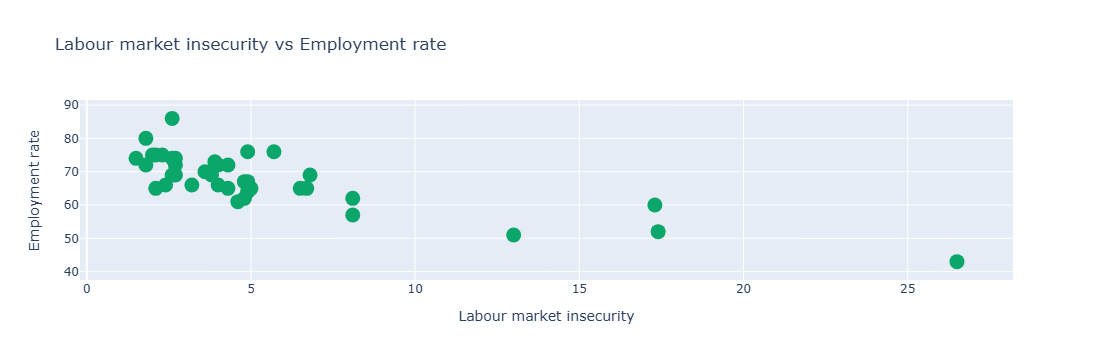

In [19]:
iplot(go.Figure(data= data,layout=layout))

W kolejnym przykładzie połączymy dwa rodzaje wykresów na jednym płótnie. W tym celu stworzymy trzy różne wektory danych:

In [20]:
import numpy as np
x = np.arange(1900,2021)
y = np.random.randint(1000,2000,len(x))
y2 = np.random.randint(500,1000,len(x))

Oś x będzie zawierała kolejne liczby od 1900 do 2020. Wykres liniowy (y) będzie oscylował w tym samym interwale między 1000 a 2000 punktów, a wykres punktowy (y2) będzie w tym samym czasie znajdował się zaraz pod nim.

Tym razem zastosujemy podejście nr 2 - w dokumentacji Plotly najczęściej będziemy mogli spotkać się właśnie z takim sposobem tworzenia wykresów.

Obiekt Figure tworzymy na samym początku.

In [21]:
fig = go.Figure()


Po utworzeniu obiektu Figure i przypisaniu go do zmiennej fig, wywołujemy na nim metodę add_trace, co jest równoznaczne z dodaniem kolejnego trace0, trace1, trace2 do listy przypisanej do zmiennej data

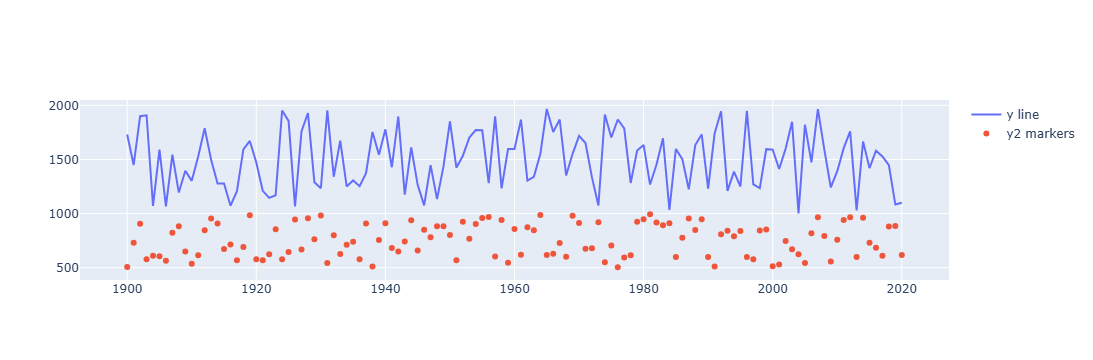

In [22]:
# Wykres liniowy
fig.add_trace(go.Scatter(x=x,y=y,name='y line'))

# Wykres punktowy
fig.add_trace(go.Scatter(x=x,y=y2,name='y2 markers',mode='markers'))

Warto zwrócić uwagę, że chcąc stworzyć wykres liniowy, korzystamy z go.Scatter – możemy go uzupełnić o argument mode=’line’, lecz ze względu na fakt, że mode=’line’ to domyślna wartość go.Scatter – nie jest to warunek konieczny.

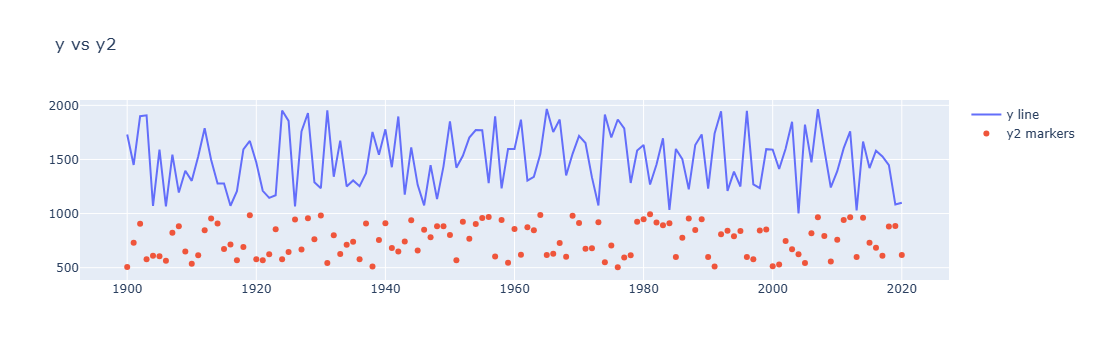

In [23]:
fig.update_layout(title='y vs y2')

Ponieważ domyślny layout został stworzony w momencie utworzenia obiektu Figure, w tym momencie robimy wyłącznie jego update.

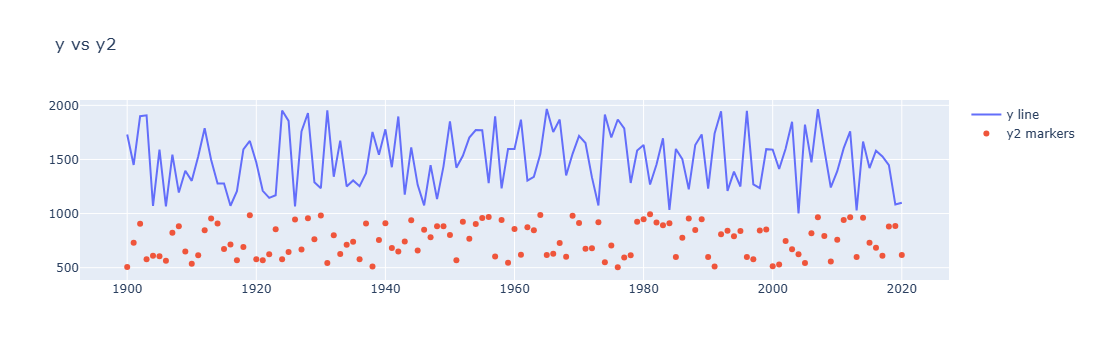

In [24]:
iplot(fig)

#KOLORY

Na przykładzie wykresu kolumnowego pokażemy możliwość własnego dostosowywania kolorów na wykresie. Na początek stworzymy wykres kolumnowy o takiej samej charakterystyce jak w części poświęconej cufflinks. Przedstawimy na niej państwa OECD pod kątem stopy zatrudnienia w kolejności malejącej.

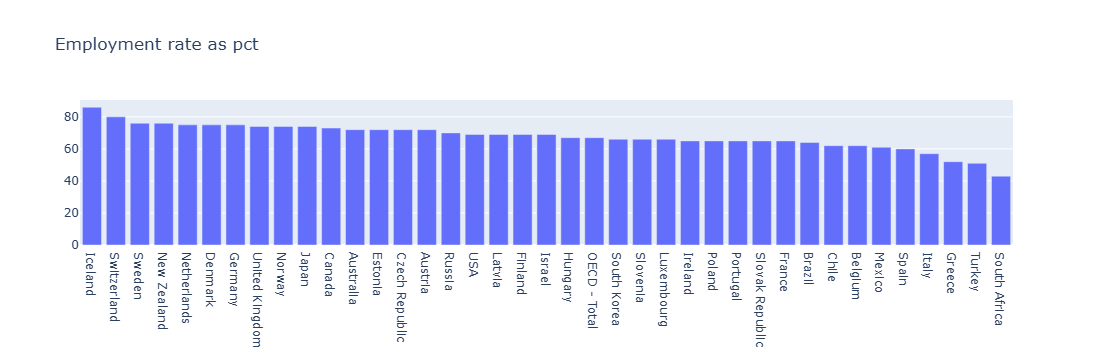

In [25]:
fig = go.Figure()  # tworzy pusty obiekt wykresu Plotly

data = df.sort_values(by='Employment rate as pct', ascending=False)  # sortuje dane malejąco według employment rate

fig.add_trace(  # dodaje wykres słupkowy do figury
    go.Bar(
        x=data['Country'],  # dane dla osi X (kraje)
        y=data['Employment rate as pct']  # dane dla osi Y (employment rate)
    )
)

fig.update_layout(title='Employment rate as pct')  # ustawia tytuł wykresu

iplot(fig)  # wyświetla interaktywny wykres

Załóżmy teraz, że chcielibyśmy na tym wykresie wyróżnić jeden punkt — średnią dla wszystkich krajów OECD. Aby tego dokonać, wystarczy, że utworzymy listę zawierającą kolory odpowiadające punktom na osi y.

In [26]:
fig = go.Figure()  # tworzy pusty obiekt wykresu Plotly

colors = ['lightslategray',] * len(data)  # tworzy listę kolorów (domyślnie szare) o długości równej liczbie wierszy w data

colors[data['Country'].tolist().index('OECD - Total')] = 'crimson'  # zmienia kolor słupka dla "OECD - Total" na czerwony

Utworzyliśmy listę zawierającą nazwy kolorów, jakimi będziemy chcieli stylizować wykres kolumnowy. Wszystkie słupki będą koloru ‘lightslategray’ oprócz tego, który odpowiada pozycji ‘OECD - Total’.

data = df.sort_values(by='

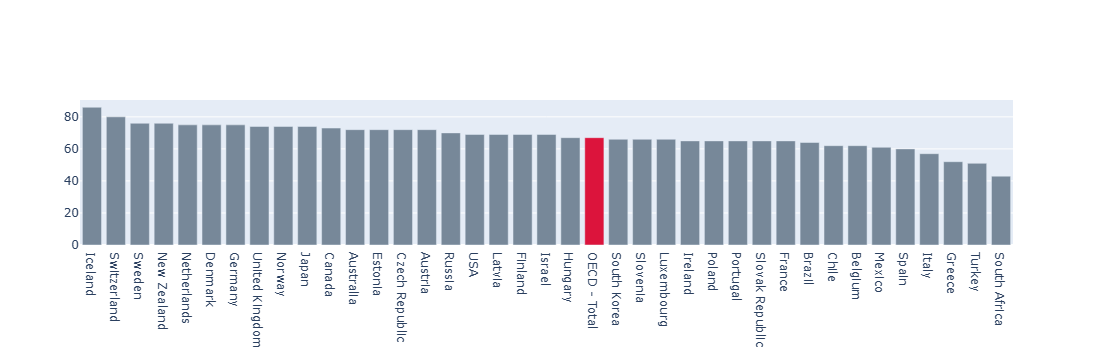

In [27]:
data = df.sort_values(by='Employment rate as pct',ascending=False)

fig.add_trace(go.Bar(x=data['Country'],y=data['Employment rate as pct'],marker_color=colors))

Wystarczy, że utworzoną w ten sposób listą kolorów uzupełnimy argument marker_color w obiekcie go.Bar.

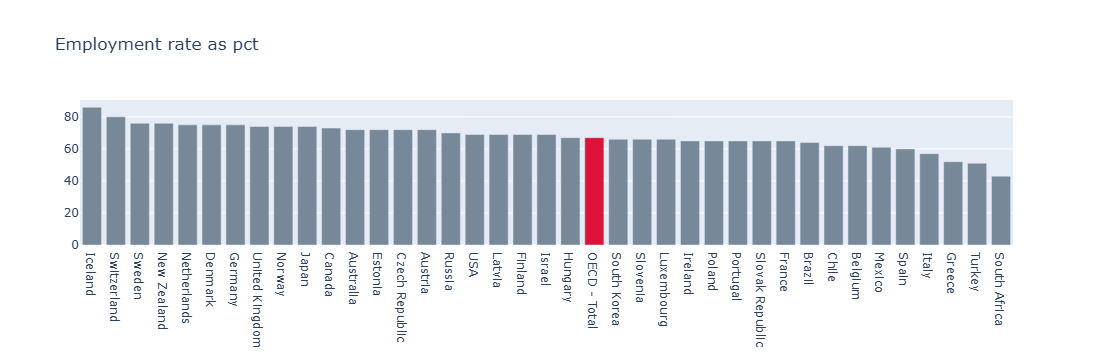

In [28]:
fig.update_layout(title='Employment rate as pct')

iplot(fig)

W ten sposób użytkownikowi końcowemu łatwiej jest zorientować się, czy dane państwo leży powyżej, czy też poniżej średniej.

Spróbujmy jeszcze zestawić ze sobą więcej niż jedną serię danych na wykresie kolumnowym.

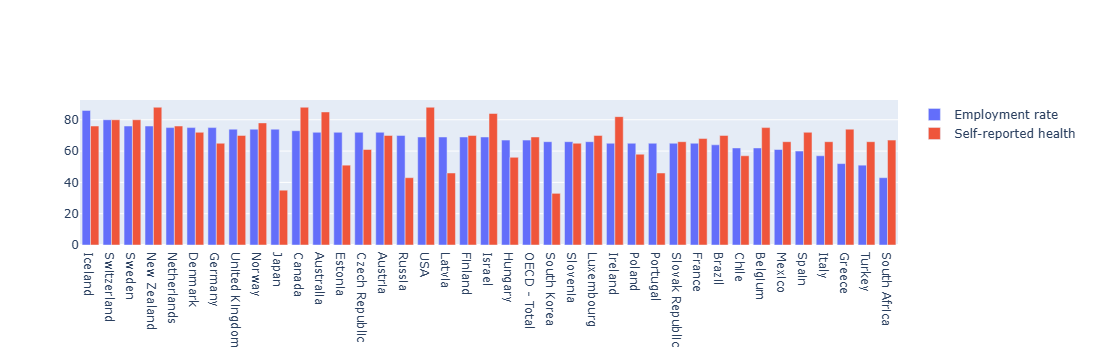

In [29]:
fig = go.Figure()  # tworzy pustą figurę (wykres)

data = df.sort_values(by='Employment rate as pct', ascending=False)  # sortuje dane malejąco według wskaźnika zatrudnienia

fig.add_trace(  # dodaje pierwszy wykres słupkowy
    go.Bar(
        x=data['Country'],  # oś X: kraje
        y=data['Employment rate as pct'],  # oś Y: stopa zatrudnienia
        name='Employment rate'  # nazwa serii danych (legenda)
    )
)

fig.add_trace(  # dodaje drugi wykres słupkowy
    go.Bar(
        x=data['Country'],  # oś X: kraje
        y=data['Self-reported health as pct'],  # oś Y: samoocena zdrowia
        name='Self-reported health'  # nazwa serii danych (legenda)
    )
)

Dla tych samych punktów na osi x zestawiamy dwie serie danych osi y — stopę zatrudnienia oraz samoocenę stanu zdrowia.

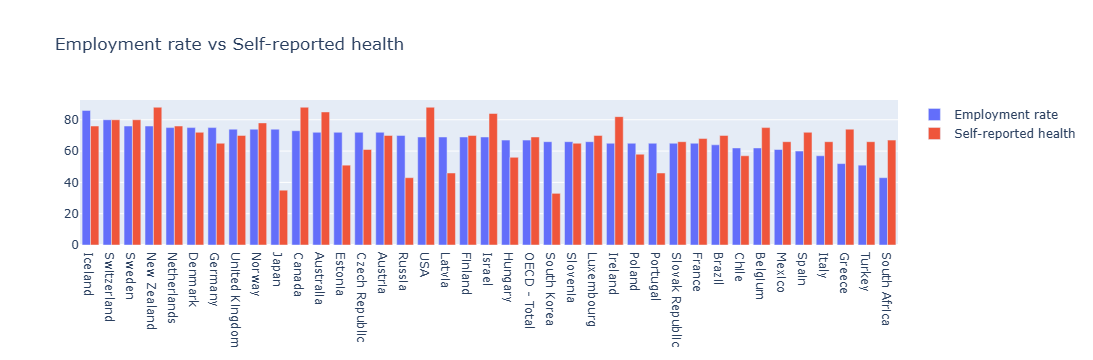

In [30]:
fig.update_layout(title='Employment rate vs Self-reported health')

# JA TEGO NIE WIDZE 

Dzięki takiemu zestawieniu możemy zauważyć, że mieszkańcy państw z pierwszego kwartyla rozkładu stopy zatrudnienia wyżej oceniają swój stan zdrowia niż mieszkańcy państw, których stopa zatrudnienia mieści się w okolicy mediany rozkładu.

W tym momencie wykres, który tworzymy, będzie miał dwa osobne słupki dla każdego punktu danych na osi x. Gdybyśmy chcieli je zestawić jeden na drugim, musielibyśmy uaktualnić layout o parametr barmode=’stack’.

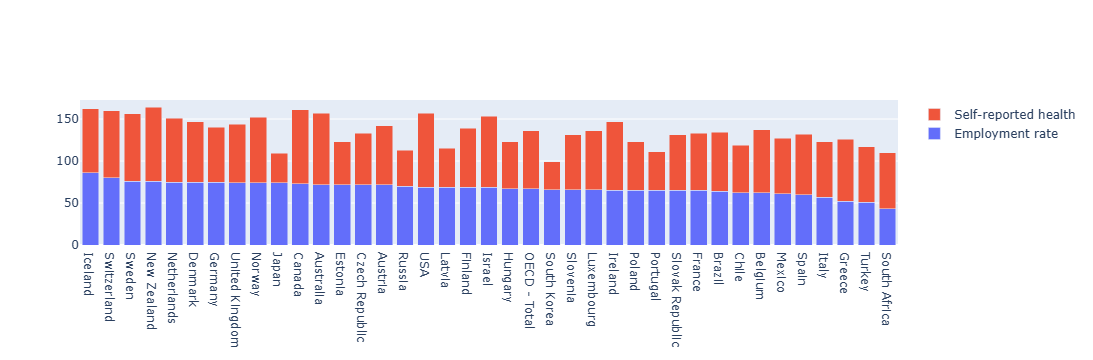

In [31]:
fig = go.Figure()  # tworzy pustą figurę (wykres)

data = df.sort_values(by='Employment rate as pct', ascending=False)  # sortuje dane malejąco według stopy zatrudnienia

fig.add_trace(  # dodaje pierwszy wykres słupkowy
    go.Bar(
        x=data['Country'],  # oś X: kraje
        y=data['Employment rate as pct'],  # oś Y: stopa zatrudnienia
        name='Employment rate'  # nazwa serii w legendzie
    )
)

fig.add_trace(  # dodaje drugi wykres słupkowy
    go.Bar(
        x=data['Country'],  # oś X: kraje
        y=data['Self-reported health as pct'],  # oś Y: samoocena zdrowia
        name='Self-reported health'  # nazwa serii w legendzie
    )
)

fig.update_layout(  # aktualizuje ustawienia wykresu
    barmode='stack'  # ustawia słupki jako skumulowane (stacked bars)
)

Ponownie zestawimy kraje OECD pod kątem zanieczyszczenia powietrza na osi x oraz jakości wody pitnej na osi y, a także zamożności gospodarstw domowych odwzorowanej przez rozmiar punktu.

Wykorzystamy tym razem własny sposób nadawania kolorów punktom, tak aby zwizualizować przynależność kraju do odpowiedniego regionu.

Wczytajmy do projektu plik csv o nazwie countrynames, pobierz go.

In [33]:
cn = pd.read_csv('countrynames.csv')
cn.head()

,name,alpha-2,alpha-3,country-code,iso_3166-2,region,sub-region,region-code,sub-region-code
0,Afghanistan,AF,AFG,4.0,ISO 3166-2:AF,Asia,Southern Asia,142.0,34.0
1,Åland Islands,AX,ALA,248.0,ISO 3166-2:AX,Europe,Northern Europe,150.0,154.0
2,Albania,AL,ALB,8.0,ISO 3166-2:AL,Europe,Southern Europe,150.0,39.0
3,Algeria,DZ,DZA,12.0,ISO 3166-2:DZ,Africa,Northern Africa,2.0,15.0
4,American Samoa,AS,ASM,16.0,ISO 3166-2:AS,Oceania,Polynesia,9.0,61.0


Baza zawiera listę krajów oraz m.in. ich kodów według standardów ISO. Interesuje nas kolumna region, na podstawie której będziemy mogli przypisać region do konkretnego państwa z bazy OECD.

In [34]:
df['Region'] = df['Country'].map(cn.set_index('name')['region'])

Udało nam się zmapować region z bazą OECD, na podstawie której będziemy tworzyć wykres.

In [35]:
colors = df['Region'].map(dict(zip(df['Region'].unique(),['Green','Blue','Red','Yellow','Gray','Black'])))

Operacja, którą wykonaliśmy powyżej, polega na związaniu regionów (kolejno: Oceania, Europa, Ameryka Północna i Południowa, Azja, Inny, Afryka) z konkretnym kolorem (kolejno: Green, Blue, Red, Yellow, Gray, Black), a następnie zmapowaniu tych kolorów, tak aby odpowiadały kolejnym państwom z bazy danych OECD.

Teraz możemy stworzyć wykres bąbelkowy. W tym celu wykorzystujemy obiekt go.Scatter.

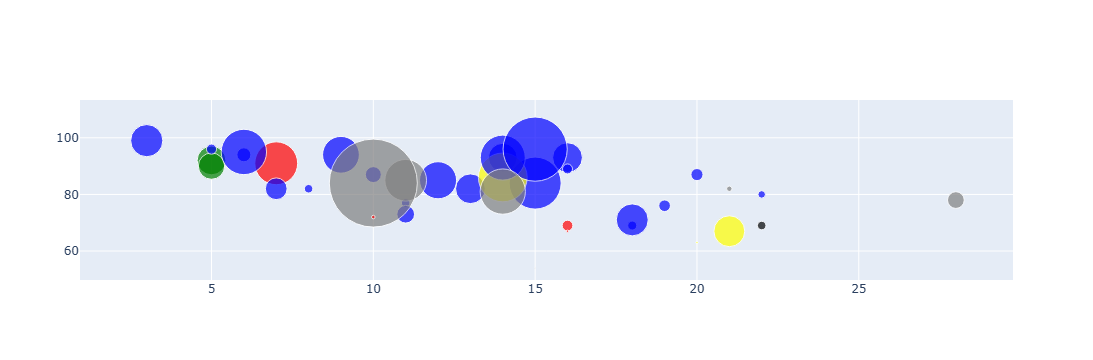

In [36]:
fig = go.Figure()  # tworzy pustą figurę wykresu Plotly

fig.add_trace(  # dodaje wykres punktowy (scatter plot)
    go.Scatter(
        x=df['Air pollution in ugm3'],  # oś X: poziom zanieczyszczenia powietrza
        y=df['Water quality as pct'],  # oś Y: jakość wody (%)
        text=df['Country'],  # tekst wyświetlany po najechaniu (nazwa kraju)
        mode='markers',  # tylko punkty (bez linii)
        marker=dict(  # ustawienia wyglądu punktów
            size=df['Household net financial wealth in usd'] / 2000,  # rozmiar punktów zależny od majątku
            color=colors  # kolory punktów (lista kolorów zdefiniowana wcześniej)
        )
    )
)

Musimy znowu pamiętać o ustaleniu opcji mode na wartość 'markers'. Aby uwzględnić wielkość punktu, do argumentu marker wprowadzamy słownik, którego jednym z kluczy jest size, a wartością wektor danych dotyczący zamożności gospodarstw domowych. Drugą parą key-value tego słownika jest color=colors, co pozwoli uwzględnić kolor regionu.

Zwróćmy uwagę, że w tym przykładzie wektor zamożności gospodarstw domowych dzielimy przez arbitralną wartość 2000. Skalujemy w ten sposób punkty, tak aby jednocześnie zachować relację pomiędzy jednym krajem a drugim, ale także, aby wykres był czytelny, a punkty nie były ani zbyt duże, ani zbyt małe.

Kończymy wykres, uaktualniając layout. Dodajemy tytuł oraz słowniki z parametrami opisującymy xaxis oraz yaxis.

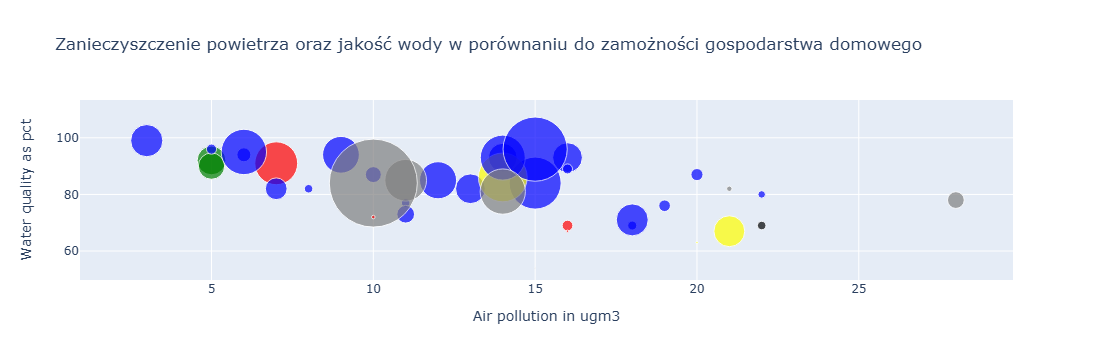

In [37]:
fig.update_layout(title='Zanieczyszczenie powietrza oraz jakość wody w porównaniu do zamożności gospodarstwa domowego',
                 xaxis=dict(title='Air pollution in ugm3'),
                 yaxis=dict(title='Water quality as pct'))

iplot(fig)

Takie zestawienie daje użytkowi obraz tego, z jakich regionów pochodzą kraje umieszczone pomiędzy osiami x oraz y. Powinniśmy popracować nad mapowaniem regionów do poszczególnych krajów — możemy zauważyć, że krajom takim jak: USA, Zjednoczone Królestwo oraz Korea Południowa nie został przypisany żaden region.

# HEATMAP

Po raz pierwszy w tym szkoleniu pokażemy, że pierwszych przekształceń danych możemy dokonać już na etapie wczytywania pliku csv do obiektu DataFrame.

In [38]:
wro_temp = pd.read_csv(
    'dataexport_20200613T163949.csv',  # nazwa pliku CSV do wczytania
    skiprows=9,  # pomija pierwsze 9 wierszy (np. metadane w pliku)
    index_col=0,  # ustawia pierwszą kolumnę jako indeks DataFrame
    parse_dates=True  # automatycznie konwertuje indeks na typ daty (datetime)
)

wro_temp.head()  # wyświetla pierwsze 5 wierszy danych

,Wrocław Temperature [2 m elevation corrected],Wrocław Precipitation Total,Wrocław Wind Speed [10 m],Wrocław Wind Direction [10 m]
timestamp,,,,
2020-06-01 00:00:00,13.444630,0.0,11.038736,8.325638
2020-06-01 01:00:00,12.224629,0.0,10.738927,7.125000
2020-06-01 02:00:00,11.424629,0.0,10.922400,12.680374
2020-06-01 03:00:00,10.614630,0.0,10.084568,12.200455
2020-06-01 04:00:00,9.784630,0.0,9.155017,8.365875


W pierwszej kolejności, poprzez argument skiprows, określamy, że chcemy pominąć pierwsze wiersze pliku csv, które zawierają dla nas nieistotne informacje. Poprzez index_col=0 każemy traktować pierwszą kolumnę pliku csv jako index DataFrame. Ustawienie opcji parse_dates na wartość True sprawi, że Pandas postara się automatycznie rozpoznać format indeksu jako obiekt Datetime.

Interaktywną heatmapę z użyciem biblioteki Plotly tworzymy w zupełnie inny sposób niż w przypadku pakietu Seaborn. Zgodnie z tym ostatnim, najpierw przekształcaliśmy DataFrame do postaci, która mogła być potem bezpośrednio przekształcona na wykres.

W Plotly natomiast ustalamy wektory osi x oraz y, a także wskazujemy zmienną, która ma być ujęta pomiędzy tymi osiami.

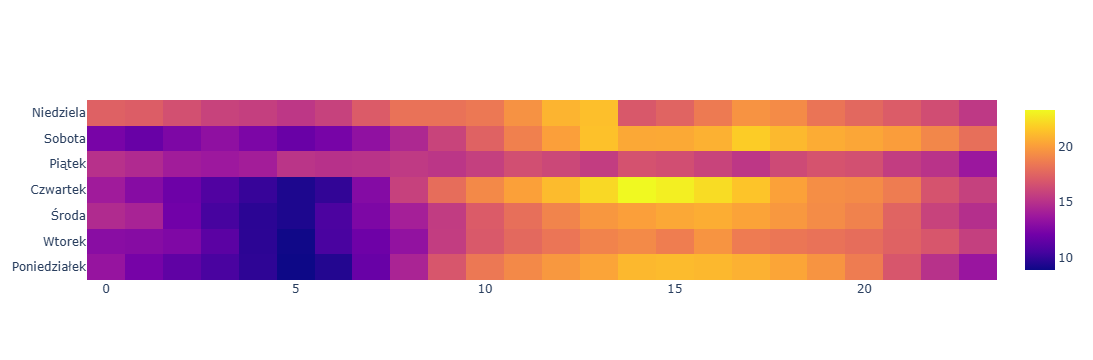

In [40]:
fig = go.Figure()  # tworzy pustą figurę wykresu Plotly

fig.add_trace(  # dodaje mapę cieplną (heatmap)
    go.Heatmap(
        x=wro_temp.index.hour,  # oś X: godzina z indeksu czasu
        y=wro_temp.index.weekday.map({  # oś Y: dzień tygodnia zamieniony na nazwy
            0: 'Poniedziałek',
            1: 'Wtorek',
            2: 'Środa',
            3: 'Czwartek',
            4: 'Piątek',
            5: 'Sobota',
            6: 'Niedziela'
        }),
        z=wro_temp['Wrocław Temperature [2 m elevation corrected]'].tolist()  # wartości temperatury jako macierz do heatmapy
    )
)

Jako oś x będziemy traktować kolejne godziny w ciągu dnia, a jako oś y kolejne dni tygodnia. W tym celu próbujemy dostać się do atrybutów hour oraz weekday dla indeksu. Poza tym mapujemy numeryczne wartości dni tygodnia uzyskanie dzięki atrybutowi weekday na reprezentację słowną tego dnia w języku polskim.

Zwróćmy również uwagę, że wektor będący podstawą heatmapy (temperatura) musi w tym przypadku zostać przekształcony na listę za pomocą funkcji tolist.

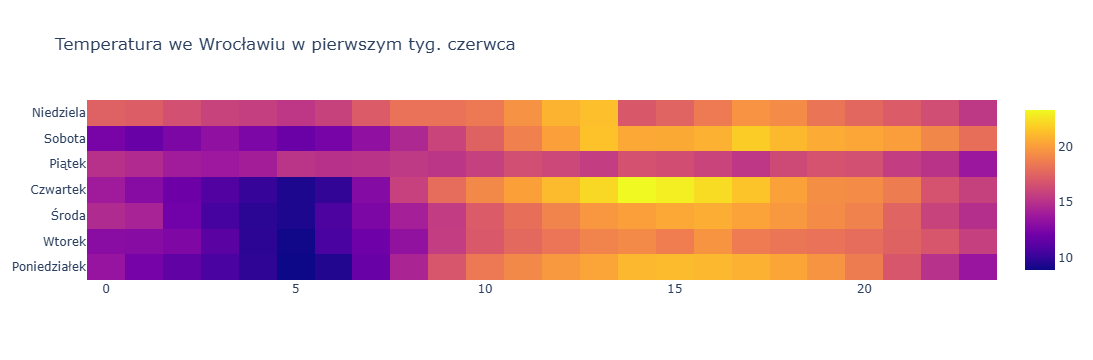

In [41]:
fig.update_layout(title='Temperatura we Wrocławiu w pierwszym tyg. czerwca')
iplot(fig)

Udało nam się stworzyć heatmapę temperatury w pierwszym tygodniu czerwca 2020 we Wrocławiu. Mając opanowane tworzenie pojedynczego wykresu, zastanówmy się teraz, w jaki sposób umieścić oba w jednym miejscu — jeden obok drugiego.

W tym celu stworzymy nowy podstawowy obiekt. Zamiast go.Figure wykorzystamy tools.make_subplots. Najpierw jednak musimy importować tools z pakietu Plotly.

# TOOLS.MAKE_SUBPLOTS

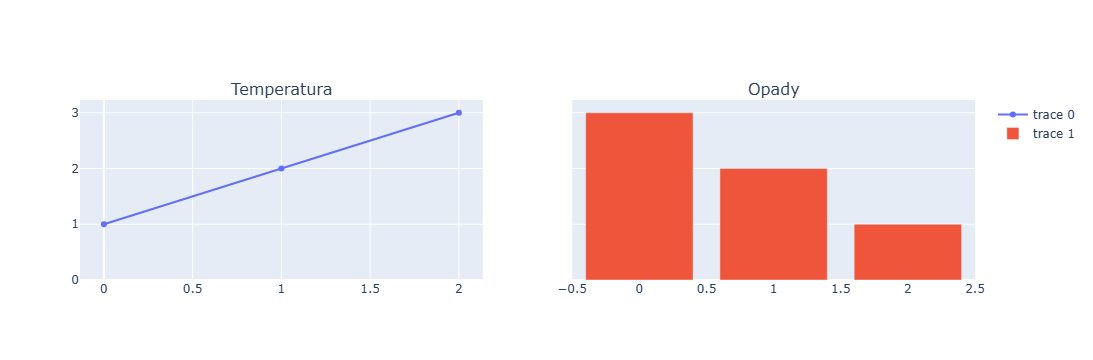

In [47]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=['Temperatura', 'Opady'],
    shared_yaxes=True
)

fig.add_trace(
    go.Scatter(y=[1, 2, 3]),
    row=1, col=1
)

fig.add_trace(
    go.Bar(y=[3, 2, 1]),
    row=1, col=2
)

fig.show()

Wewnątrz precyzujemy, że chodzi nam o jeden wiersz i dwie kolumny wykresów. Dodatkowo dodajemy subplot_titles odpowiadające tytułom wykresów w kolejnych kolumnach. Na końcu ustawiamy jeszcze opcję shared_yaxes na True – dzięki temu na wykresach zestawionych obok siebie nie będziemy powtarzać kolejnych dni tygodnia od poniedziałku do piątku według osi y.

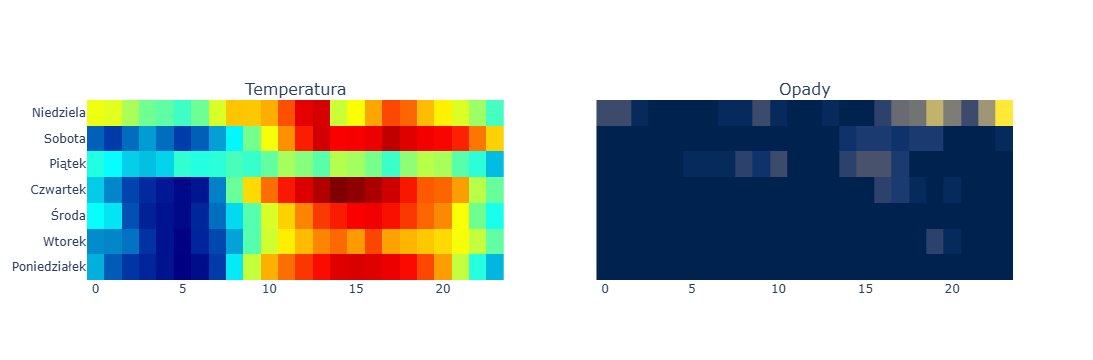

In [54]:
from plotly.subplots import make_subplots  # import funkcji do tworzenia wykresów w układzie subplotów
import plotly.graph_objects as go  # import obiektów wykresów (scatter, bar, heatmap itd.)

fig = make_subplots(  # tworzy figurę z wieloma wykresami (subploty)
    rows=1,  # liczba wierszy w układzie wykresów
    cols=2,  # liczba kolumn w układzie wykresów
    subplot_titles=['Temperatura', 'Opady'],  # tytuły dla każdego subplotu
    shared_yaxes=True  # współdzielona oś Y między wykresami
)

fig.add_trace(  # dodaje pierwszy wykres (temperatura) do figury
    go.Heatmap(  # tworzy mapę cieplną
        x=wro_temp.index.hour,  # oś X: godzina z indeksu czasu
        y=wro_temp.index.weekday.map({  # oś Y: dzień tygodnia zamieniony na nazwy
            0:'Poniedziałek', 1:'Wtorek', 2:'Środa',
            3:'Czwartek', 4:'Piątek', 5:'Sobota', 6:'Niedziela'
        }),
        z=wro_temp['Wrocław Temperature [2 m elevation corrected]'].tolist(),  # wartości temperatury
        colorscale='Jet',  # paleta kolorów dla temperatury
        showscale=False  # wyłącza pasek kolorów
    ),
    1, 1  # pozycja: wiersz 1, kolumna 1
)

fig.add_trace(  # dodaje drugi wykres (opady)
    go.Heatmap(  # tworzy mapę cieplną
        x=wro_temp.index.hour,  # oś X: godzina
        y=wro_temp.index.weekday.map({  # oś Y: dni tygodnia
            0:'Poniedziałek', 1:'Wtorek', 2:'Środa',
            3:'Czwartek', 4:'Piątek', 5:'Sobota', 6:'Niedziela'
        }),
        z=wro_temp['Wrocław Precipitation Total'].tolist(),  # wartości opadów
        colorscale='Cividis',  # paleta kolorów dla opadów
        showscale=False  # wyłącza pasek kolorów
    ),
    1, 2  # pozycja: wiersz 1, kolumna 2
)

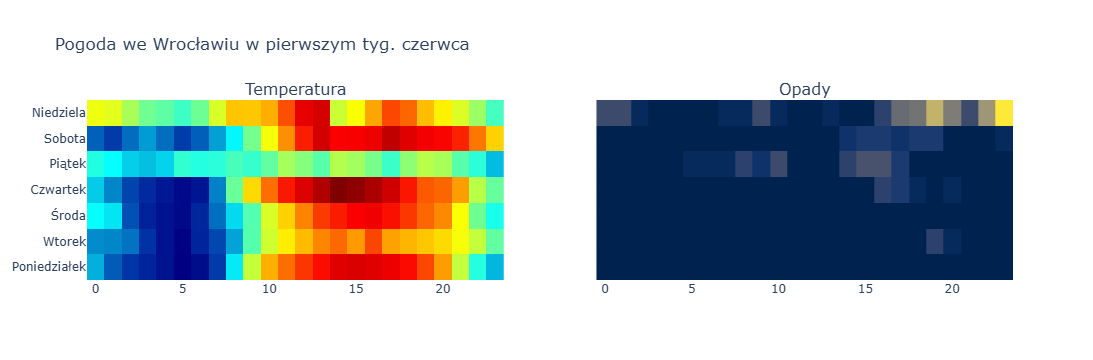

In [55]:
fig.update_layout(title='Pogoda we Wrocławiu w pierwszym tyg. czerwca')
iplot(fig)

# Kartogramy

Kartogram jest metodą prezentacji statystycznych wartości danego zjawiska na mapie — w podziale na określone jednostki przestrzenne (kraje, stany, województwa, miasta itp.). Kartogramy bardzo często możemy zaobserwować, przeglądając statystyki gęstości zaludnienia lub przy okazji omawiania wyników wyborów, kiedy poszczególne jednostki administracyjne są wyróżnione kolorami kojarzonymi ze zwycięską opcją polityczną z tego obszaru.

Plotly umożliwia nam stworzenie domyślnych kartogramów mapy świata w podziale na kraje oraz mapy Stanów Zjednoczonych w podziale na poszczególne stany. Wykorzystanie swojej mapy wiąże się z wczytaniem odpowiedniego pliku geojson do silnika Plotly.

W ramach ćwiczenia stworzymy kartogram przedstawiający średni poziom dochodów osobistych wyrażonych w USD dla wszystkich krajów OECD.

Wczytujemy do projektu statystyki krajów OECD z 2017 roku (tych danych używaliśmy w poprzednich submodułach, więc powinny być dostępne w twoim projekcie):

In [57]:
df = pd.read_csv('OECDBLI2017.csv')

Naszym zadaniem będzie naniesienie na mapę świata danych z kolumny Personal earnings in USD.

Tworzenie kartogramu przebiega w podobny do innych wykresów sposób:

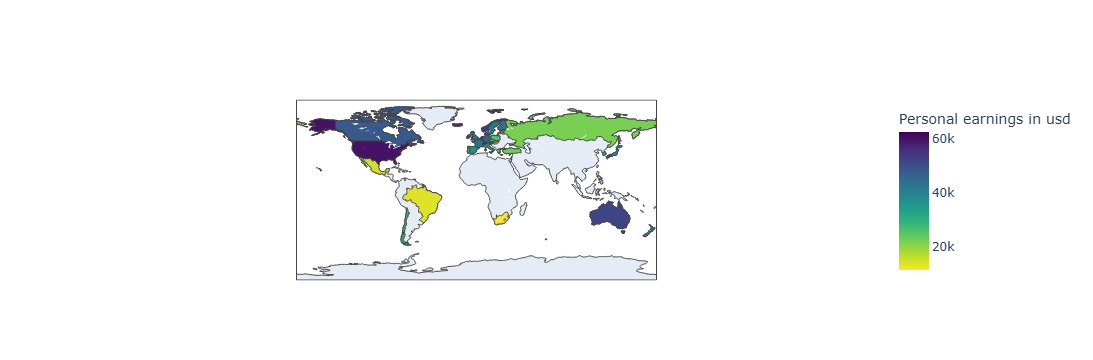

In [59]:
fig = go.Figure()  # tworzy pustą figurę wykresu Plotly

fig.add_trace(  # dodaje wykres mapy (choropleth) do figury
    go.Choropleth(  # tworzy mapę kolorystyczną krajów
        colorscale='Viridis',  # ustawia skalę kolorów (ciemny → jasny)
        reversescale=True,  # odwraca skalę kolorów (wysokie wartości = ciemniejsze/jaśniejsze w odwrotny sposób)
        locations=df['Country'],  # nazwy krajów używane do mapowania na mapę świata
        locationmode='country names',  # określa, że identyfikacja odbywa się po nazwach krajów
        z=df['Personal earnings in usd'],  # wartości liczbowe przypisane do krajów (kolorowanie mapy)
        colorbar=dict(  # konfiguracja paska kolorów
            title='Personal earnings in usd'  # tytuł legendy kolorów
        )
    )
)

Obiekt go.Choropleth inicjujemy z następującymi opcjami:

Wybieramy paletę kolorów, z jakiej chcemy korzystać (colorscale=’Viridis’).
Obok mapy pojawi się skala mapująca kolory do poszczególnych poziomów zamożności. Poprzez reversescale precyzujemy, żeby skala była przedstawiona w sposób malejący: od najwyższej do najniższej wartości.
Przy locations wskazujemy listę krajów, na podstawie której Plotly będzie nanosić wartości na mapę.
Tworząc mapę świata na podstawie zwyczajowych nazw państw, musimy wybrać jedną z dostępnych opcji locationmode: tj. ‘country names’. Domyślną wartością tej zmiennej jest ‘ISO-3’, nasza baza danych nie zawiera jednak nazw krajów w tym formacie.
Przy z określamy jakie wartości chcemy nanieść na mapę. W naszym przypadku jest to kolumna Personal earnings in USD.

Na koniec sprawdźmy jeszcze inne rodzaje projekcji mapy, np. natural earth.

In [63]:
geo= dict(showframe=False,projection={'type':'natural earth'})

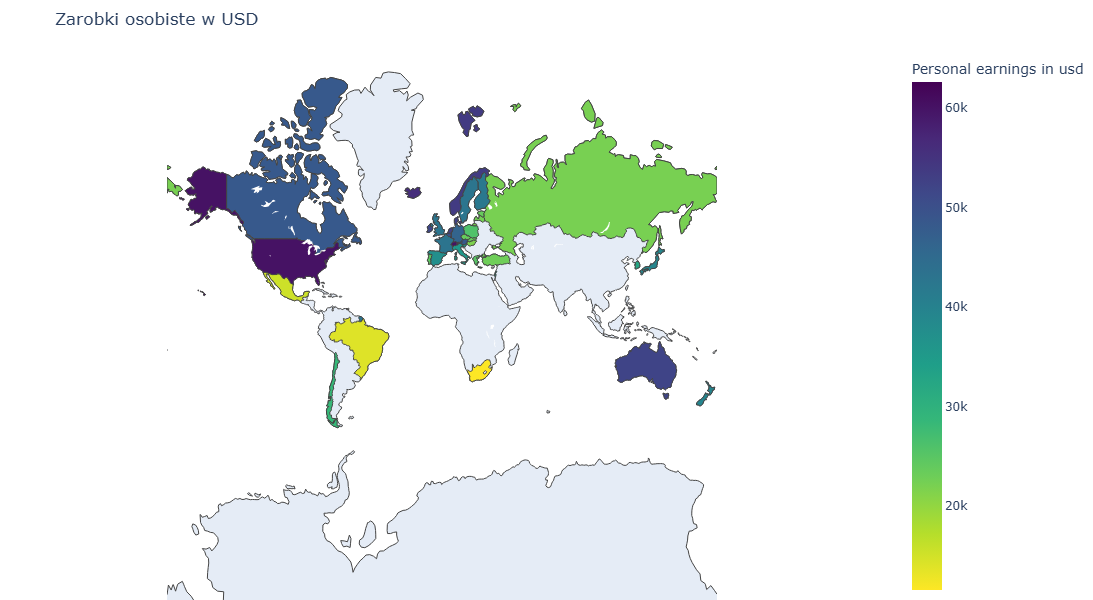

In [64]:
iplot(fig)

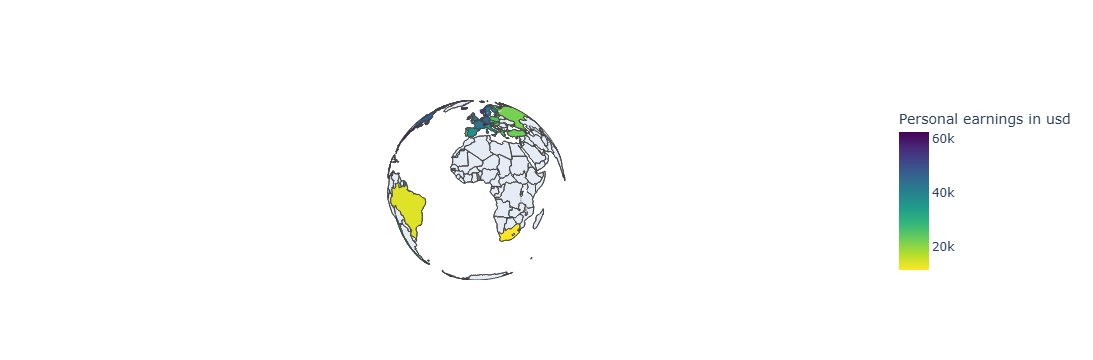

In [67]:
fig = go.Figure()

fig.add_trace(go.Choropleth(
    colorscale='Viridis',
    reversescale=True,
    locations=df['Country'],
    locationmode='country names',
    z=df['Personal earnings in usd'],
    colorbar=dict(title='Personal earnings in usd')
))

fig.update_layout(
    geo=dict(
        projection_type='orthographic',  # 🌍 efekt globusa
        showframe=False,  # usuwa ramkę
        showcoastlines=True,  # linie wybrzeży
        showcountries=True  # granice krajów
    )
)